# Custom Mask Inference Demo
This notebook demonstrates how to feed a custom risk-mapped mask into the FNOSDF and PNO pipeline to generate a cost-to-go map, using actual goals and ground truth from the dataset.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from models.fno import FNO2d
from models.deepnormMultiGoal import DEEPNORM2dMultiGoal

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load Data and Create Custom Mask
We load the distance map, goal, and ground truth output from the city dataset.

In [2]:
data_dir = "dataset/cityData/256x256/"
dist_maps = np.load(data_dir + "dist_in.npy")
goal_maps = np.load(data_dir + "goal.npy")
output_maps = np.load(data_dir + "output.npy")
actual_masks = np.load(data_dir + "mask.npy")

# Choose map index 6
map_idx = 6
dist_map = dist_maps[map_idx]
goal_data = goal_maps[map_idx][::-1] # Swap to [row, col] for correct indexing
gt_output = output_maps[map_idx]
actual_mask = actual_masks[map_idx]

sigma = 3.0
risk_map = np.exp(-(dist_map ** 2)/(2 * sigma ** 2))
risk_map = (risk_map - risk_map.min()) / (risk_map.max() - risk_map.min())

# Create binary masks at different thresholds
thresholds = np.arange(0.1, 1, 0.1)
layer_masks = []
for t in thresholds:
    mask = np.where(risk_map < t, 1.0, 0.0)
    layer_masks.append(mask)

layer_masks = np.array(layer_masks)
print(f"Map Index: {map_idx}")
print(f"Goal Coordinates: {goal_data}")
print(f"Generated {len(layer_masks)} layer masks with shape {layer_masks[0].shape}")

Map Index: 6
Goal Coordinates: [143 159]
Generated 9 layer masks with shape (256, 256)


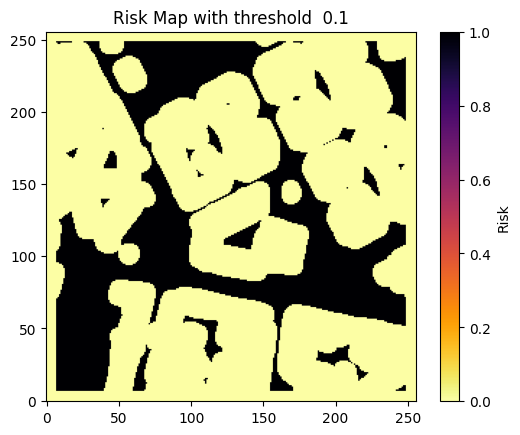

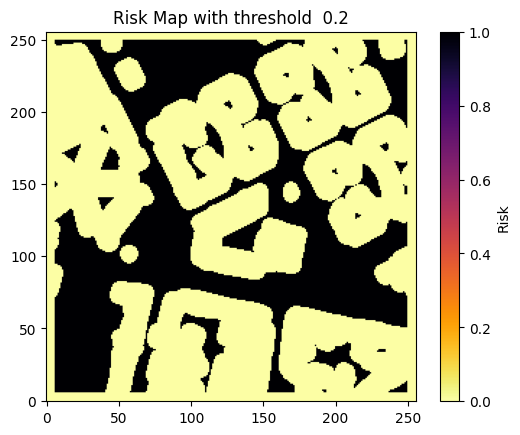

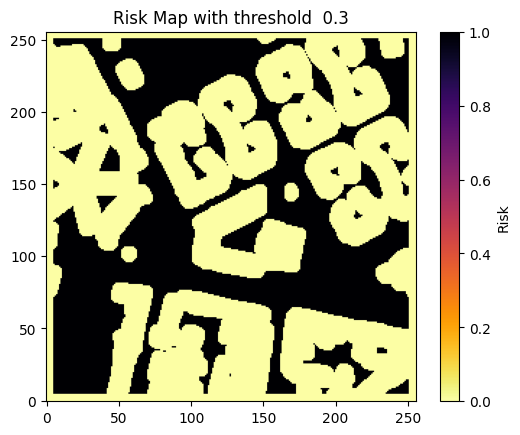

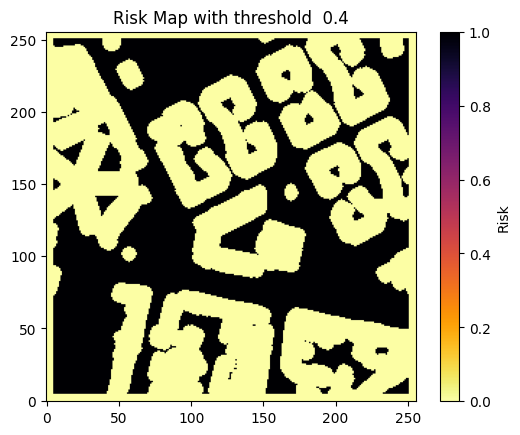

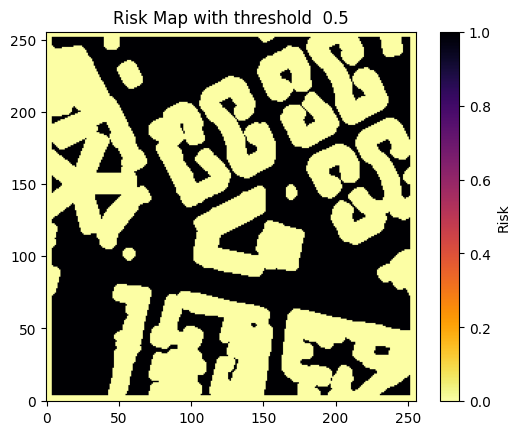

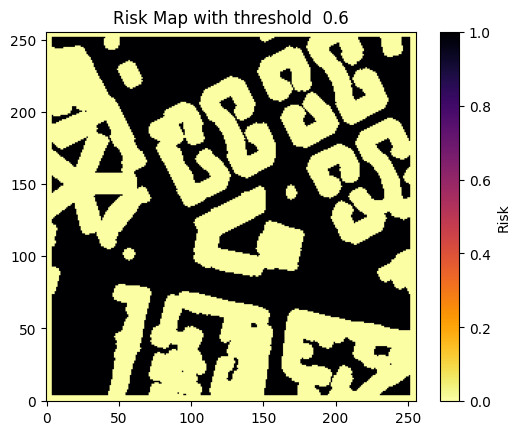

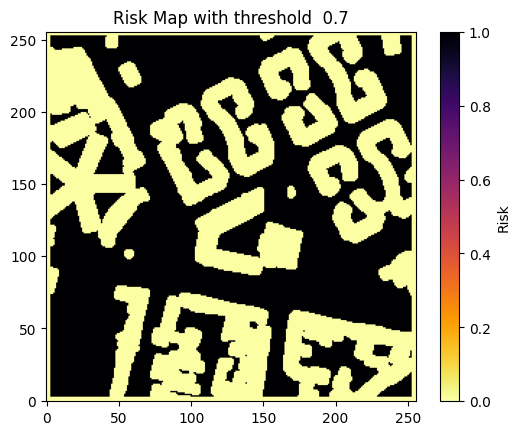

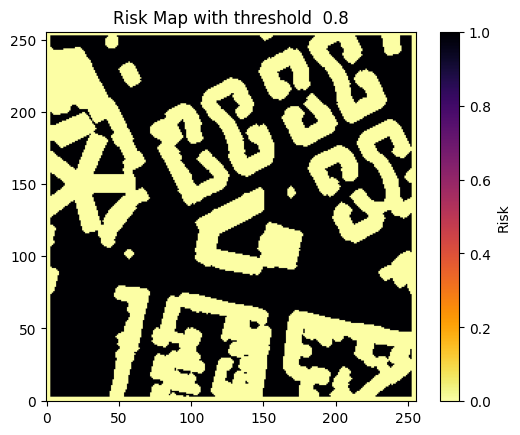

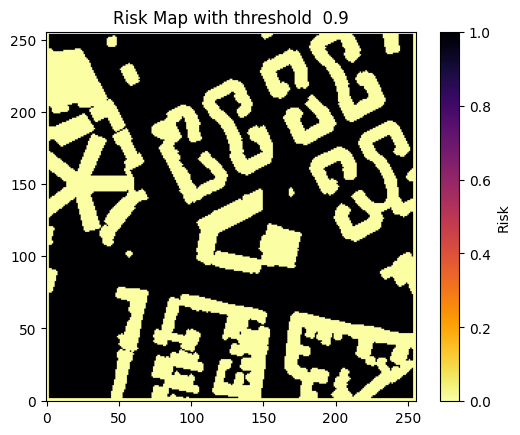

In [3]:
for i, mask in enumerate(layer_masks):
    plt.imshow(mask, cmap='inferno_r', origin='lower')
    plt.colorbar(label='Risk')
    plt.title(f'Risk Map with threshold {i/10 + 0.1: .1f}')
    plt.show()
    plt.close()

## 2. Load Pretrained Models

In [4]:
# 1. Load FNOSDF
modelSDF = FNO2d(4, 1, 8, 8, 16).to(device)
try:
    modelSDF.load_state_dict(torch.load("./results/FNOSDF/best_model.pt", map_location=device, weights_only=True))
    print("Loaded FNOSDF model weights.")
except FileNotFoundError:
    print("Error: FNOSDF weights not found.")
modelSDF.eval()

# 2. Load PNO
modelPNO = DEEPNORM2dMultiGoal(4, 8, 8, 16).to(device)
try:
    modelPNO.load_state_dict(torch.load("./results/PNO/best_model.pt", map_location=device, weights_only=True))
    print("Loaded PNO model weights.")
except FileNotFoundError:
    print("Error: PNO weights not found.")
modelPNO.eval()

# 3. Load PNOwPINN
modelPNOwPINN = DEEPNORM2dMultiGoal(4, 8, 8, 16).to(device)
try:
    modelPNOwPINN.load_state_dict(torch.load("./results/PNOwPINN/best_model.pt", map_location=device, weights_only=True))
    print("Loaded PNOwPINN model weights.")
except FileNotFoundError:
    print("Error: PNOwPINN weights not found.")
modelPNOwPINN.eval()

Loaded FNOSDF model weights.
Loaded PNO model weights.
Loaded PNOwPINN model weights.


DEEPNORM2dMultiGoal(
  (fc0): Linear(in_features=2, out_features=16, bias=True)
  (conv0): SpectralConv2d()
  (w0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv1): SpectralConv2d()
  (w1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv2): SpectralConv2d()
  (w2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (conv3): SpectralConv2d()
  (w3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (fc1): DeepNormMetric(
    (Us): ModuleList(
      (0-1): 2 x Linear(in_features=16, out_features=128, bias=False)
    )
    (Ws): ModuleList(
      (0): ConstrainedLinear(in_features=128, out_features=128, bias=False)
    )
    (activation): MaxReLUPairwiseActivation(
      (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    )
    (output_activation): ConcaveActivation()
    (reduce_metric): ReduceMetric()
  )
)

## 3. Inference Pipeline
We process all layer masks, average their SDFs and masks, and run both PNO models using the dataset goal.

In [5]:
def smooth_chi(mask, dist, smooth_coef=5.0):
    return torch.mul(torch.tanh(dist * smooth_coef), (mask - 0.5)) + 0.5

# 1. Run FNOSDF for all 9 masks
all_sdfs = []
all_masks = []

for mask in layer_masks:
    mask_tensor = torch.tensor(mask, dtype=torch.float).reshape(1, 256, 256, 1).to(device)
    with torch.no_grad():
        sdf = modelSDF(mask_tensor)
    all_sdfs.append(sdf)
    all_masks.append(mask_tensor)

# 2. Average the 9 SDFs and the 9 Masks
avg_sdf = torch.mean(torch.stack(all_sdfs), dim=0)
avg_mask = torch.mean(torch.stack(all_masks), dim=0)

# 3. Compute Smoothed Chi from averaged values
chi = smooth_chi(avg_mask, avg_sdf, 5.0)

# 4. Define Goal from dataset
goal_coord = torch.tensor([goal_data], dtype=torch.int).to(device)

with torch.no_grad():
    # 5. Predict Cost-to-go
    cost_to_go_PNO = modelPNO(chi, goal_coord)
    cost_to_go_PNOwPINN = modelPNOwPINN(chi, goal_coord)
    
    # 6. Mask the output
    cost_to_go_masked_PNO = cost_to_go_PNO * avg_mask
    cost_to_go_masked_PNOwPINN = cost_to_go_PNOwPINN * avg_mask

print("Inference complete.")

Inference complete.


/var/folders/6q/zk1mvksx6x5c7zdtm6nb9vr40002xh/T/ipykernel_67028/269512810.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  goal_coord = torch.tensor([goal_data], dtype=torch.int).to(device)


## 4. Visualization

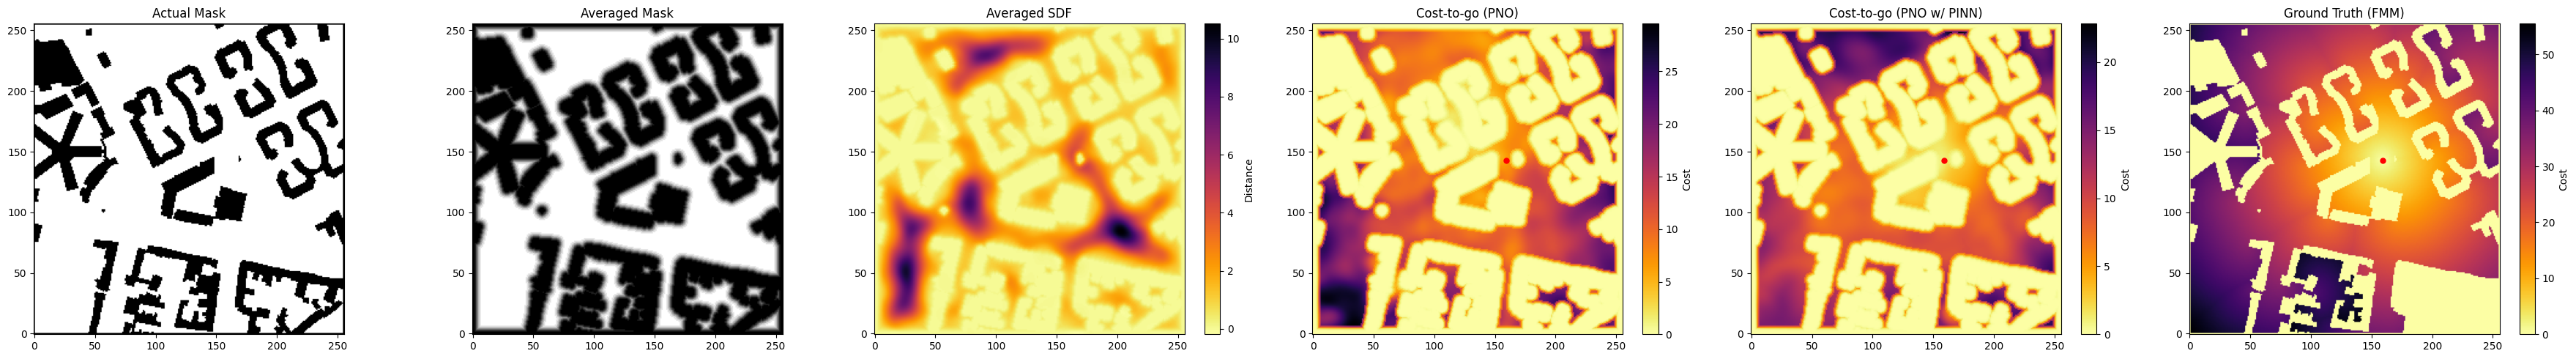

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(36, 5))

# axis 0: actual ground truth mask
axes[0].imshow(actual_mask, origin="lower", cmap="gray")
axes[0].set_title("Actual Mask")

# axis 1: averaged risk-mapped masks
axes[1].imshow(avg_mask[0].cpu().numpy().squeeze(), origin="lower", cmap="gray")
axes[1].set_title("Averaged Mask")

im1 = axes[2].imshow(avg_sdf[0].cpu().numpy().squeeze(), origin="lower", cmap="inferno_r")
axes[2].set_title("Averaged SDF")
fig.colorbar(im1, ax=axes[2], label="Distance")

im2 = axes[3].imshow(cost_to_go_masked_PNO[0].cpu().numpy().squeeze(), origin="lower", cmap="inferno_r")
axes[3].plot(goal_data[1], goal_data[0], "ro", markersize=5) # Plot as (x, y)
axes[3].set_title("Cost-to-go (PNO)")
fig.colorbar(im2, ax=axes[3], label="Cost")

im3 = axes[4].imshow(cost_to_go_masked_PNOwPINN[0].cpu().numpy().squeeze(), origin="lower", cmap="inferno_r")
axes[4].plot(goal_data[1], goal_data[0], "ro", markersize=5) # Plot as (x, y)
axes[4].set_title("Cost-to-go (PNO w/ PINN)")
fig.colorbar(im3, ax=axes[4], label="Cost")

im4 = axes[5].imshow(gt_output.squeeze(), origin="lower", cmap="inferno_r")
axes[5].plot(goal_data[1], goal_data[0], "ro", markersize=5) # Plot as (x, y)
axes[5].set_title("Ground Truth (FMM)")
fig.colorbar(im4, ax=axes[5], label="Cost")

plt.tight_layout()
plt.show()

## 5. Path Planning with A*
We use the predicted cost-to-go map from PNO w/ PINN as a heuristic for A* planning. We'll pick a start position far from the goal and plan the path.

In [9]:
import sys
import os
import pqdict
# Add 2D_Neural_Heuristics to the path to import the astar module
heuristics_dir = os.path.abspath("../2D_Neural_Heuristics")
if heuristics_dir not in sys.path:
    sys.path.append(heuristics_dir)

from astar.astar import AStar
from astar.environment_simple import Environment2D
from astar.utilities import drawMap, drawPath2D

# 1. Prepare Environment
# cmap: 0 for free space, 1 for obstacle
cmap = 1.0 - actual_mask

# Heuristic: the predicted cost-to-go map from PNO w/ PINN
heuristic_map = cost_to_go_masked_PNOwPINN[0].cpu().numpy().squeeze()

# Create environment
env = Environment2D(goal_data, cmap, valuefunction=heuristic_map)

# 2. Select a Start Position
# Find all passable indices
passable_indices = np.argwhere(cmap == 0)
# Pick a point with a high cost-to-go as the start position to ensure a long path
valid_costs = [(idx, heuristic_map[idx[0], idx[1]]) for idx in passable_indices]
valid_costs.sort(key=lambda x: x[1], reverse=True)
start_coord = valid_costs[0][0]

print(f"Start Coordinates: {start_coord}")
print(f"Goal Coordinates: {goal_data}")

# 3. Run A* Planning
path_cost, path, action_idx, nodes_count, sss = AStar.plan(start_coord, env)

print(f"Path Cost: {path_cost}")
print(f"Number of Node Expansions: {nodes_count}")

path_array = np.asarray(path)

Start Coordinates: [248 171]
Goal Coordinates: [143 159]
Path Cost: 119.66904755831207
Number of Node Expansions: 9747


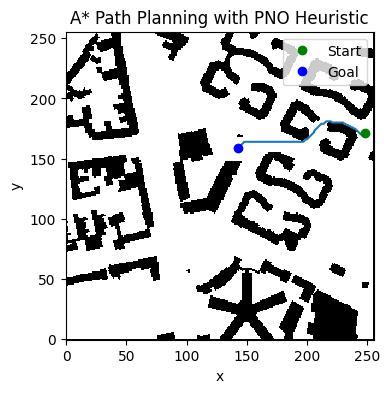

In [10]:
# 4. Visualize the path
fig, ax = plt.subplots(figsize=(6, 4))
drawMap(ax, cmap)

if len(path_array) > 0:
    drawPath2D(ax, path_array)

ax.set_title("A* Path Planning with PNO Heuristic")
plt.show()